# 01 — Exploración y análisis del dataset ISIC 2018

**Proyecto:** Skin Lesion Analysis  
**Repositorio:** https://github.com/Jesusrodriguezf90/skin-lesion-analysis  
**Fase:** Análisis exploratorio previo al entrenamiento

---

Este notebook cubre la primera fase del proyecto: la exploración y el análisis
del dataset ISIC 2018 Task 1 (segmentación) y Task 3 (clasificación).

El objetivo no es entrenar ningún modelo sino entender los datos antes de diseñar
el pipeline: distribución de clases, desbalance, estadísticas de imagen y
visualización de máscaras de segmentación.

El output de este notebook informa las decisiones de diseño de `02_segmentation.ipynb`.

In [17]:
"""
Notebook: 01_eda.ipynb

Objetivo:
    Explorar y analizar el dataset ISIC 2018 antes del entrenamiento.
    Cubre la distribución de clases (Task 3), el desbalance entre categorías,
    las estadísticas de tamaño y aspecto de las imágenes (Task 1), y la
    visualización de pares imagen-máscara de segmentación.

    Los hallazgos de este notebook determinan las decisiones de diseño
    del pipeline: estrategia de balanceo de clases, política de
    redimensionado y parámetros de augmentación.

Estrategia de datos:
    Task 1 y Task 3 son conjuntos disjuntos — se usan para tareas distintas.
    Task 1 (2.594 imágenes + máscaras) entrena el U-Net de segmentación.
    Task 3 / HAM10000 (10.015 imágenes + etiquetas) entrena el EfficientNet
    de clasificación. En inferencia el pipeline opera en secuencia:
    U-Net segmenta → EfficientNet clasifica sobre la región segmentada.

Estrategia de acceso al dataset:
    Kaggle descomprime los ZIPs automáticamente al subir el dataset —
    las imágenes y máscaras están disponibles como carpetas directas en
    /kaggle/input/. Se accede con Path + PIL sin necesidad de zipfile.
    Los notebooks de entrenamiento (02, 03, 04) siguen el mismo enfoque.

Fuente de datos:
    ISIC 2018 — Skin Lesion Analysis Towards Melanoma Detection
    Task 1: 2.594 imágenes dermoscópicas + máscaras de segmentación
    Task 3: CSV oficial HAM10000 — 10.015 imágenes + etiquetas (7 categorías)
    https://challenge.isic-archive.com/data/#2018

Autor:   Jesús Rodríguez
Fecha:   2026-05-29
Versión: 1.1.0
"""

'\nNotebook: 01_eda.ipynb\n\nObjetivo:\n    Explorar y analizar el dataset ISIC 2018 antes del entrenamiento.\n    Cubre la distribución de clases (Task 3), el desbalance entre categorías,\n    las estadísticas de tamaño y aspecto de las imágenes (Task 1), y la\n    visualización de pares imagen-máscara de segmentación.\n\n    Los hallazgos de este notebook determinan las decisiones de diseño\n    del pipeline: estrategia de balanceo de clases, política de\n    redimensionado y parámetros de augmentación.\n\nEstrategia de datos:\n    Task 1 y Task 3 son conjuntos disjuntos — se usan para tareas distintas.\n    Task 1 (2.594 imágenes + máscaras) entrena el U-Net de segmentación.\n    Task 3 / HAM10000 (10.015 imágenes + etiquetas) entrena el EfficientNet\n    de clasificación. En inferencia el pipeline opera en secuencia:\n    U-Net segmenta → EfficientNet clasifica sobre la región segmentada.\n\nEstrategia de acceso al dataset:\n    Kaggle descomprime los ZIPs automáticamente al subir 

## 1. Configuración del entorno

In [18]:
# Detección del entorno de ejecución (Kaggle vs local)
import os

IN_KAGGLE = os.path.exists("/kaggle/input")
print(f"Entorno detectado: {"Kaggle" if IN_KAGGLE else "local"}")

Entorno detectado: Kaggle


In [19]:
# Verificación del entorno de ejecución
import sys
import platform

print(f"Python : {sys.version}")
print(f"Sistema: {platform.system()} {platform.release()}")

Python : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Sistema: Linux 6.6.122+


## 2. Instalación de dependencias

In [20]:
# Instalación de dependencias de visualización y análisis
# Se instalan en modo silencioso (-q) para reducir el output en Kaggle
%pip install matplotlib seaborn pandas Pillow -q

Note: you may need to restart the kernel to use updated packages.


In [21]:
# Verificación de imports principales
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

print("Dependencias importadas correctamente")

Dependencias importadas correctamente


## 3. Definición de rutas

In [22]:
# Rutas del dataset — Kaggle descomprime los ZIPs automáticamente,
# por lo que las imágenes y máscaras son carpetas directas en /kaggle/input/
if IN_KAGGLE:
    DIR_INPUT  = Path("/kaggle/input/datasets/jesusrf1990/isic2018-skin-lesion")
    DIR_OUTPUT = Path("/kaggle/working/processed")
else:
    DIR_INPUT  = Path("data/raw")
    DIR_OUTPUT = Path("data/processed")

DIR_IMAGENES = DIR_INPUT / "ISIC2018_Task1-2_Training_Input"
DIR_MASCARAS = DIR_INPUT / "ISIC2018_Task1_Training_GroundTruth"
RUTA_CSV     = DIR_INPUT / "ISIC2018_Task3_Training_GroundTruth.csv"

DIR_OUTPUT.mkdir(parents=True, exist_ok=True)

# Validación de existencia de las rutas antes de continuar
assert DIR_IMAGENES.exists(), f"No se encontró el directorio de imágenes: {DIR_IMAGENES}"
assert DIR_MASCARAS.exists(), f"No se encontró el directorio de máscaras: {DIR_MASCARAS}"
assert RUTA_CSV.exists(),     f"No se encontró el CSV de etiquetas: {RUTA_CSV}"

print(f"Imágenes  : {DIR_IMAGENES}")
print(f"Máscaras  : {DIR_MASCARAS}")
print(f"CSV       : {RUTA_CSV}")

Imágenes  : /kaggle/input/datasets/jesusrf1990/isic2018-skin-lesion/ISIC2018_Task1-2_Training_Input
Máscaras  : /kaggle/input/datasets/jesusrf1990/isic2018-skin-lesion/ISIC2018_Task1_Training_GroundTruth
CSV       : /kaggle/input/datasets/jesusrf1990/isic2018-skin-lesion/ISIC2018_Task3_Training_GroundTruth.csv


## 4. Inventario del dataset

In [23]:
# Listado de archivos disponibles en cada directorio
imagenes = sorted(DIR_IMAGENES.glob("*.jpg"))
mascaras = sorted(DIR_MASCARAS.glob("*.png"))

print("=" * 50)
print("INVENTARIO DEL DATASET")
print("=" * 50)
print(f"  Imágenes Task 1  : {len(imagenes)}")
print(f"  Máscaras Task 1  : {len(mascaras)}")
print("=" * 50)

INVENTARIO DEL DATASET
  Imágenes Task 1  : 2594
  Máscaras Task 1  : 2594


In [24]:
# Verificación de correspondencia imagen-máscara
# Cada imagen debe tener exactamente una máscara asociada
ids_imagenes = {f.stem for f in imagenes}
ids_mascaras = {f.stem.replace("_segmentation", "") for f in mascaras}

sin_mascara = ids_imagenes - ids_mascaras
sin_imagen  = ids_mascaras - ids_imagenes

print(f"  Imágenes sin máscara : {len(sin_mascara)}")
print(f"  Máscaras sin imagen  : {len(sin_imagen)}")

if not sin_mascara and not sin_imagen:
    print("  [OK] Correspondencia imagen-máscara completa")
else:
    print("  [AVISO] Hay inconsistencias en el dataset")

  Imágenes sin máscara : 0
  Máscaras sin imagen  : 0
  [OK] Correspondencia imagen-máscara completa


## 5. Distribución de clases (Task 3 — HAM10000)

In [25]:
# Carga del CSV de etiquetas de clasificación
df = pd.read_csv(RUTA_CSV)

print(f"Filas   : {len(df)}")
print(f"Columnas: {list(df.columns)}")
df.head()

Filas   : 10015
Columnas: ['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
# Las etiquetas están en formato one-hot — convertir a columna de clase única
# para facilitar el análisis de distribución
CLASES = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

NOMBRES_CLASES = {
    "MEL"  : "Melanoma",
    "NV"   : "Melanocytic nevus",
    "BCC"  : "Basal cell carcinoma",
    "AKIEC": "Actinic keratosis",
    "BKL"  : "Benign keratosis",
    "DF"   : "Dermatofibroma",
    "VASC" : "Vascular lesion",
}

# Task 3 se explora completo — es independiente de Task 1
df_task3 = df.copy()
df_task3["clase"] = df_task3[CLASES].idxmax(axis=1)

print(f"Muestras Task 3 (HAM10000) : {len(df_task3)}")

Muestras Task 3 (HAM10000) : 10015


In [27]:
# Conteo y distribución de clases en Task 3
conteo = df_task3["clase"].value_counts()
total  = conteo.sum()

print("=" * 50)
print("DISTRIBUCIÓN DE CLASES — TASK 3 (HAM10000)")
print("=" * 50)
for clase, n in conteo.items():
    nombre = NOMBRES_CLASES[clase]
    print(f"  {clase:<6} {nombre:<25} {n:>5}  ({100*n/total:.1f}%)")
print("=" * 50)
print(f"  Total                              {total:>5}")

DISTRIBUCIÓN DE CLASES — TASK 3 (HAM10000)
  NV     Melanocytic nevus          6705  (66.9%)
  MEL    Melanoma                   1113  (11.1%)
  BKL    Benign keratosis           1099  (11.0%)
  BCC    Basal cell carcinoma        514  (5.1%)
  AKIEC  Actinic keratosis           327  (3.3%)
  VASC   Vascular lesion             142  (1.4%)
  DF     Dermatofibroma              115  (1.1%)
  Total                              10015


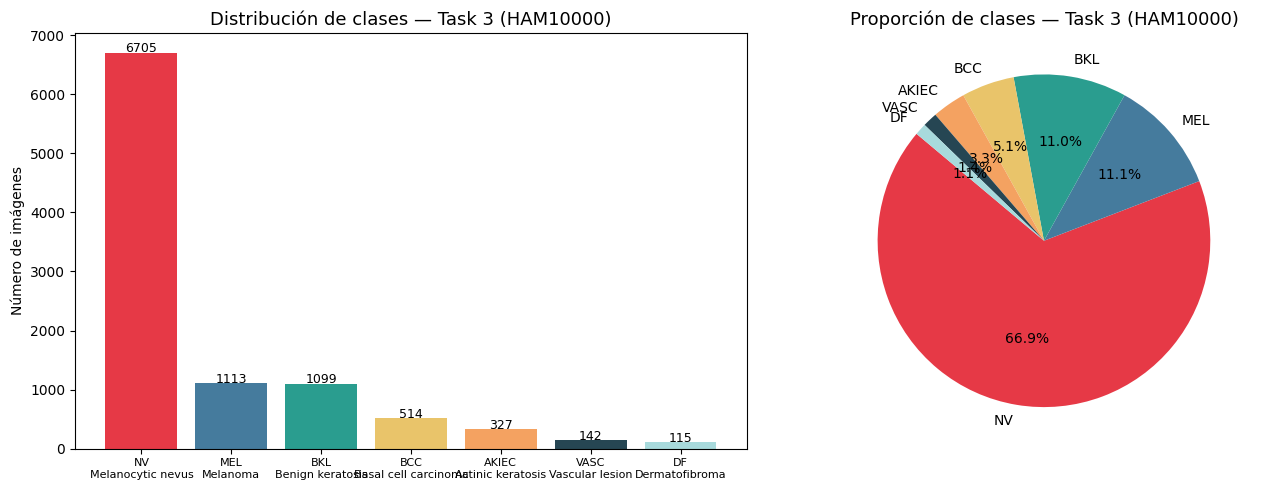

Gráfico guardado en processed/distribucion_clases.png


In [28]:
# Visualización de la distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261", "#264653", "#a8dadc"]

# Gráfico de barras
etiquetas = [f"{c}\n{NOMBRES_CLASES[c]}" for c in conteo.index]
axes[0].bar(etiquetas, conteo.values, color=colores)
axes[0].set_title("Distribución de clases — Task 3 (HAM10000)", fontsize=13)
axes[0].set_ylabel("Número de imágenes")
axes[0].tick_params(axis="x", labelsize=8)
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=9)

# Gráfico de tarta
axes[1].pie(
    conteo.values,
    labels=conteo.index,
    autopct="%1.1f%%",
    colors=colores,
    startangle=140,
)
axes[1].set_title("Proporción de clases — Task 3 (HAM10000)", fontsize=13)

plt.tight_layout()
plt.savefig(DIR_OUTPUT / "distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en processed/distribucion_clases.png")

## 6. Análisis del desbalance de clases

In [29]:
# Cálculo del ratio de desbalance respecto a la clase mayoritaria
clase_mayoritaria = conteo.idxmax()
n_mayoritaria     = conteo.max()

print("=" * 55)
print("RATIO DE DESBALANCE — TASK 3 (HAM10000)")
print("=" * 55)
for clase, n in conteo.items():
    ratio = n_mayoritaria / n
    print(f"  {clase:<6} {n:>5} muestras   ratio vs NV: {ratio:>5.1f}x")
print("=" * 55)
print(f"  Clase mayoritaria : {clase_mayoritaria} ({n_mayoritaria} muestras)")
print(f"  Clase minoritaria : {conteo.idxmin()} ({conteo.min()} muestras)")

RATIO DE DESBALANCE — TASK 3 (HAM10000)
  NV      6705 muestras   ratio vs NV:   1.0x
  MEL     1113 muestras   ratio vs NV:   6.0x
  BKL     1099 muestras   ratio vs NV:   6.1x
  BCC      514 muestras   ratio vs NV:  13.0x
  AKIEC    327 muestras   ratio vs NV:  20.5x
  VASC     142 muestras   ratio vs NV:  47.2x
  DF       115 muestras   ratio vs NV:  58.3x
  Clase mayoritaria : NV (6705 muestras)
  Clase minoritaria : DF (115 muestras)


## 7. Estadísticas de tamaño de imagen (Task 1)

In [30]:
# Muestreo aleatorio para estimar la distribución de tamaños
# Leer las 2.594 imágenes completas sería costoso —
# 200 muestras son suficientes para una estimación fiable
random.seed(42)
MUESTRA_N = 200
muestra   = random.sample(imagenes, min(MUESTRA_N, len(imagenes)))

anchos, altos = [], []
for ruta in muestra:
    img = Image.open(ruta)
    w, h = img.size
    anchos.append(w)
    altos.append(h)

print("=" * 45)
print(f"ESTADÍSTICAS DE TAMAÑO — TASK 1 (n={len(anchos)})")
print("=" * 45)
print(f"  Ancho  — min: {min(anchos)}  max: {max(anchos)}  media: {np.mean(anchos):.0f}")
print(f"  Alto   — min: {min(altos)}  max: {max(altos)}  media: {np.mean(altos):.0f}")
print("=" * 45)

ESTADÍSTICAS DE TAMAÑO — TASK 1 (n=200)
  Ancho  — min: 576  max: 6708  media: 3089
  Alto   — min: 542  max: 4461  media: 2111


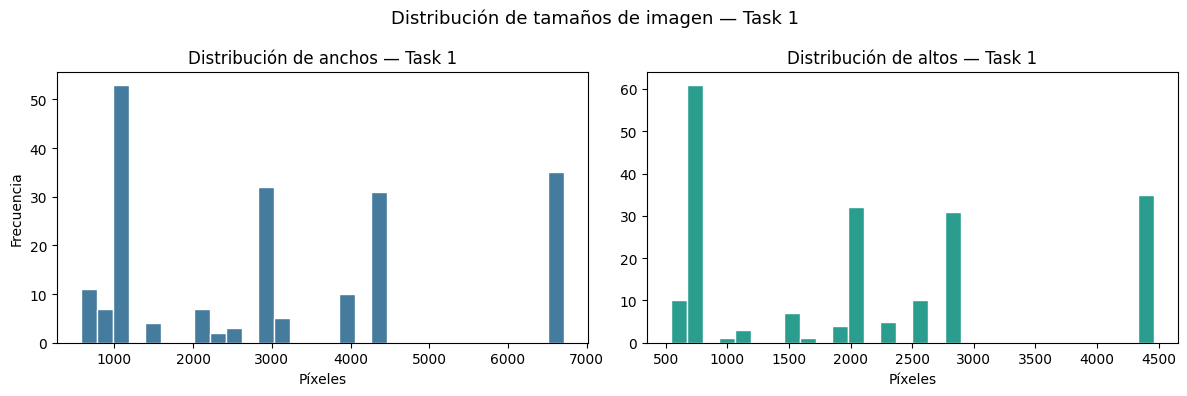

In [31]:
# Visualización de la distribución de tamaños
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(anchos, bins=30, color="#457b9d", edgecolor="white")
axes[0].set_title("Distribución de anchos — Task 1")
axes[0].set_xlabel("Píxeles")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(altos, bins=30, color="#2a9d8f", edgecolor="white")
axes[1].set_title("Distribución de altos — Task 1")
axes[1].set_xlabel("Píxeles")

plt.suptitle("Distribución de tamaños de imagen — Task 1", fontsize=13)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / "distribucion_tamanos.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Visualización de pares imagen-máscara (Task 1)

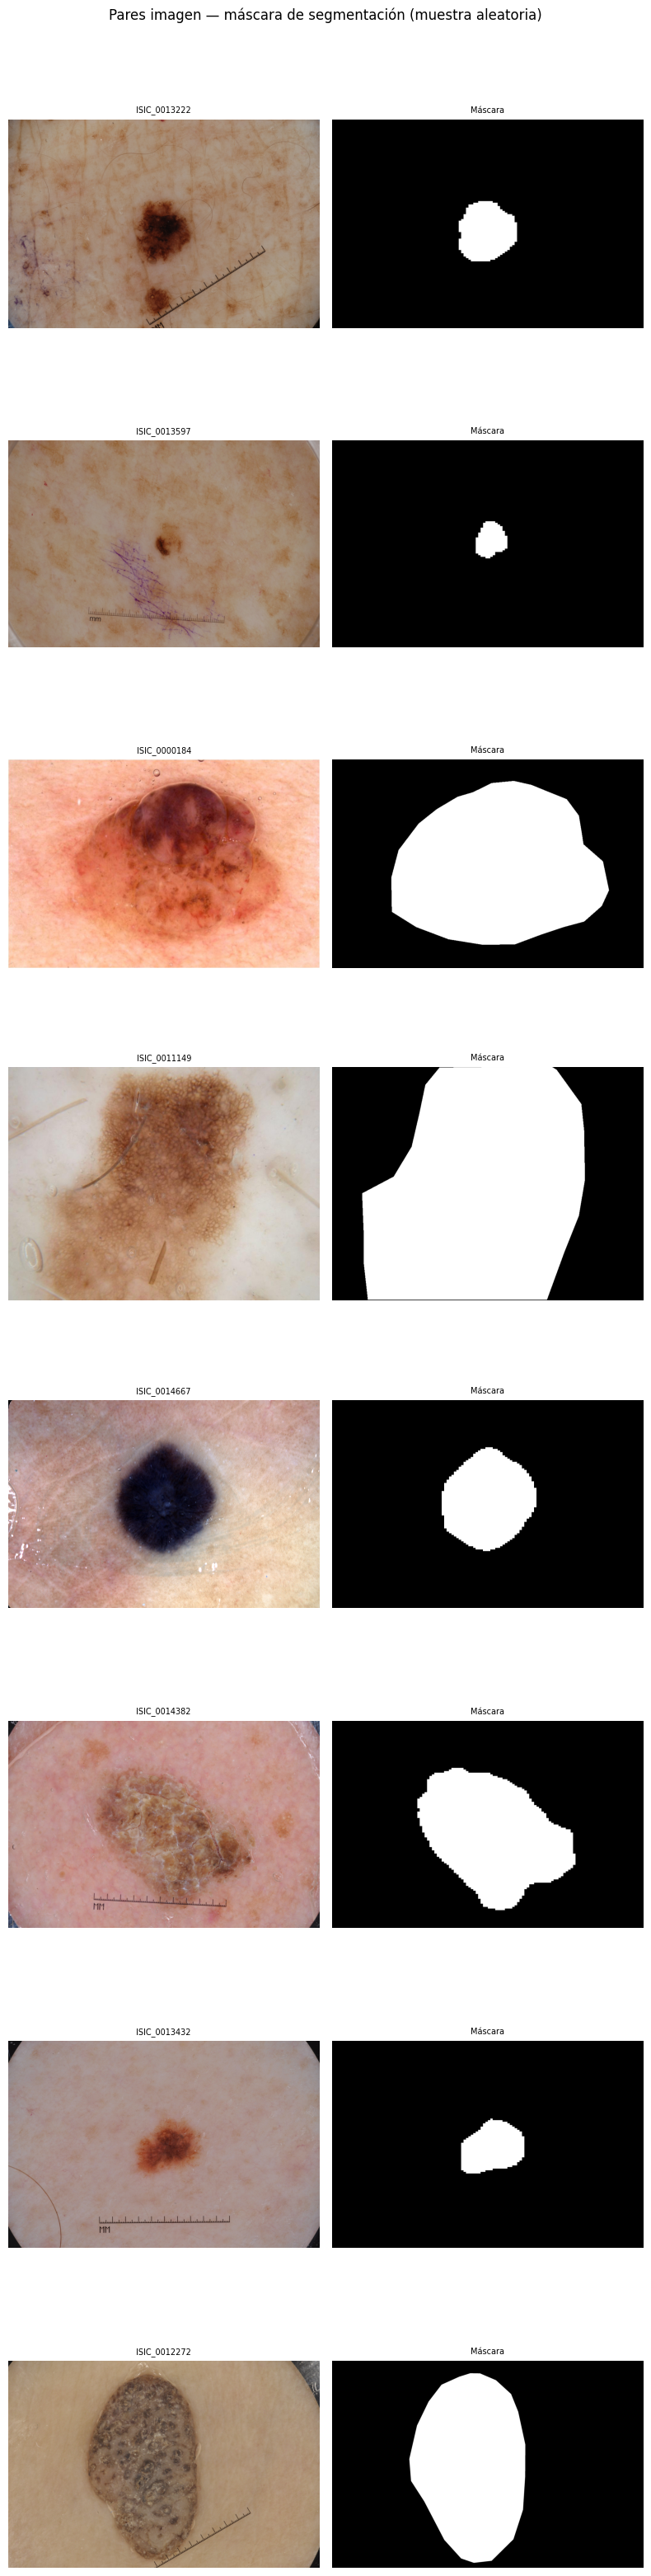

In [32]:
# Visualización de 8 pares imagen-máscara aleatorios
# para verificar la calidad del ground truth de segmentación
random.seed(0)
muestra_viz = random.sample(imagenes, 8)

fig, axes = plt.subplots(8, 2, figsize=(8, 32))

for i, ruta_img in enumerate(muestra_viz):
    ruta_mask = DIR_MASCARAS / (ruta_img.stem + "_segmentation.png")

    img  = np.array(Image.open(ruta_img))
    mask = np.array(Image.open(ruta_mask).convert("L"))

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(ruta_img.stem, fontsize=7)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Máscara", fontsize=7)
    axes[i, 1].axis("off")

plt.suptitle("Pares imagen — máscara de segmentación (muestra aleatoria)", fontsize=12, y=1.001)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / "pares_imagen_mascara.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Análisis de la cobertura de máscara (Task 1)

In [33]:
# Porcentaje de píxeles de lesión sobre el total de la imagen
# Indica qué fracción del frame ocupa la lesión de media
coberturas = []

for ruta_img in muestra:
    ruta_mask = DIR_MASCARAS / (ruta_img.stem + "_segmentation.png")
    mask      = np.array(Image.open(ruta_mask).convert("L"))
    cobertura = (mask > 127).sum() / mask.size
    coberturas.append(cobertura)

coberturas = np.array(coberturas)

print("=" * 45)
print("COBERTURA DE MÁSCARA — TASK 1")
print("=" * 45)
print(f"  Media  : {coberturas.mean()*100:.1f}%")
print(f"  Mediana: {np.median(coberturas)*100:.1f}%")
print(f"  Mín    : {coberturas.min()*100:.1f}%")
print(f"  Máx    : {coberturas.max()*100:.1f}%")
print("=" * 45)

COBERTURA DE MÁSCARA — TASK 1
  Media  : 21.7%
  Mediana: 17.7%
  Mín    : 0.6%
  Máx    : 88.6%


## 10. Resumen y conclusiones

In [34]:
# Resumen de los hallazgos del EDA y su implicación para el pipeline
print("=" * 60)
print("RESUMEN — EDA ISIC 2018")
print("=" * 60)
print(f"  Imágenes Task 1 (segmentación)  : {len(imagenes)}")
print(f"  Imágenes Task 3 (clasificación) : {len(df_task3)}")
print(f"  Clases                          : {len(CLASES)}")
print(f"  Clase mayoritaria               : NV ({conteo['NV']} muestras)")
print(f"  Clase minoritaria               : {conteo.idxmin()} ({conteo.min()} muestras)")
print(f"  Ratio de desbalance máx         : {n_mayoritaria / conteo.min():.1f}x")
print(f"  Cobertura media de máscara      : {coberturas.mean()*100:.1f}%")
print("=" * 60)
print()
print("Implicaciones para el pipeline:")
print("  - U-Net entrena con Task 1 (2.594 imágenes + máscaras)")
print("  - EfficientNet entrena con Task 3 / HAM10000 (10.015 imágenes)")
print("  - Usar weighted loss o oversampling en clasificación")
print("  - Redimensionar a 224x224 con padding para preservar aspecto")
print("  - Normalizar con media/std de ImageNet (encoder preentrenado)")
print("=" * 60)
print("Siguiente paso: 02_segmentation.ipynb")

RESUMEN — EDA ISIC 2018
  Imágenes Task 1 (segmentación)  : 2594
  Imágenes Task 3 (clasificación) : 10015
  Clases                          : 7
  Clase mayoritaria               : NV (6705 muestras)
  Clase minoritaria               : DF (115 muestras)
  Ratio de desbalance máx         : 58.3x
  Cobertura media de máscara      : 21.7%

Implicaciones para el pipeline:
  - U-Net entrena con Task 1 (2.594 imágenes + máscaras)
  - EfficientNet entrena con Task 3 / HAM10000 (10.015 imágenes)
  - Usar weighted loss o oversampling en clasificación
  - Redimensionar a 224x224 con padding para preservar aspecto
  - Normalizar con media/std de ImageNet (encoder preentrenado)
Siguiente paso: 02_segmentation.ipynb
